In [1]:
import os
from glob import glob
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import normalized_root_mse as nrmse

from cardiac.bulleye_gen import gen_bulleye

from cardiac.segment.functions import naive_segment_lv_mask, naive_cal_circle_param

from cardiac.segment.advanced_segment import cal_lv_mask, cal_lv_mask2


In [2]:

import cv2
import numpy as np
from scipy.optimize import minimize
from skimage.measure import regionprops
from scipy.ndimage import gaussian_filter1d
from scipy.ndimage import label, center_of_mass
from scipy.interpolate import RegularGridInterpolator

def naive_cal_circle_param(img3d, lv_mask, factor=0.8):
    z_len, y_len, x_len = img3d.shape
    if np.sum(lv_mask):
        zs,_,_ = np.where(lv_mask==1)
        s_start = np.min(zs)
        s_end = np.max(zs)
    else:
        print(f"lv_mask is None")
        slice_len = int(z_len*factor)
        s_start = (z_len - slice_len)//2
        s_end = z_len-s_start
    
    sliced_img3d = img3d[s_start:s_end].copy()
    summed_img2d = np.sum(sliced_img3d, axis=0)
    max_intensity = np.max(summed_img2d)
    intensity_mask = summed_img2d > (0.5 * max_intensity)
    
    Y, X = np.ogrid[:y_len, :x_len]
    # 计算质心作为圆心
    cy, cx = center_of_mass(intensity_mask)
    
    distance2center = np.sqrt((X - cy) ** 2 + (X - cx) ** 2)
    # 拟合固定圆心的半径 radius, 使得在半径最靠近 数值高圆环的区域, 且圆周处 值最高(表示心肌中线)
    cost_func = lambda params: np.sum(summed_img2d*intensity_mask * (np.abs(np.sqrt((X - params[1]) ** 2 + (X - params[2]) ** 2) - params[0])))
    
    # 初始猜测：图像中心作为圆心，半径初始值为图像尺寸的 1/3 ~ 10
    result = minimize(cost_func, x0 = [summed_img2d.shape[0] / 3, 32, 32], bounds=[(5, 18), (27, 38), (27, 38)])
    radius, cy, cx = result.x  # 拟合得到的半径

    circle_param = {
        "center": {
            "cy": cy,
            "cx": cx,
        },
        "radius": radius,
    }
    # 这是用来显示用的
    others = {
            "summed_img2d": summed_img2d,
            "intensity_mask": intensity_mask
        }
    print(222)
    return circle_param, others

In [3]:
base_dir = r"Y:\labspace\DataCollection\Project\RadiSmart\cardiac\all_nii"

dir_names = sorted(os.listdir(base_dir))


total_data = {}


    

def cal_metric(std_polar_map, input_polar_map):

    # 计算 PSNR
    psnr_value = psnr(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())

    ssim_value = ssim(std_polar_map, input_polar_map, data_range=std_polar_map.max() - std_polar_map.min())
    # 计算 NRMSE
    nrmse_value = nrmse(std_polar_map, input_polar_map)


    print(f"PSNR: {psnr_value}, SSIM: {ssim_value}, NRMSE: {nrmse_value}")
    
    return psnr_value, ssim_value, nrmse_value
    
    
for i,dir in enumerate(dir_names):
    img_paths = glob(os.path.join(base_dir, dir, "*.nii.gz"))
    if len(img_paths) < 2:
        continue
    
    
    img_path = glob(os.path.join(base_dir, dir, "SA*.nii.gz"))[0]
    
    sitk_img = sitk.ReadImage(img_path)
    img_arr = sitk.GetArrayFromImage(sitk_img)
    width = 20
    # 计算中心位置
    center = np.array(img_arr.shape)//2
    start = center - width//2
    end = center + width//2
    
    clipped_img_arr = img_arr[:, start[1]:end[1], start[2]:end[2]].copy()
    
    zoom_factor = 3
    zoomed_clipped_img_arr = zoom(clipped_img_arr, zoom_factor, cval=0)
    voxel_size = np.array(sitk_img.GetSpacing()[::-1])/zoom_factor
    
    # cz, cy, cx = np.array(zoomed_clipped_img_arr.shape)/2
    # apex_z = 12
    # base_z = 48
    
    zs, ys, xs = np.where(zoomed_clipped_img_arr > np.max(zoomed_clipped_img_arr)*0.35)
    apex_z = np.min(zs)
    
    zs, ys, xs = np.where(zoomed_clipped_img_arr > np.max(zoomed_clipped_img_arr)*0.65)
    # zs, ys, xs = np.where(zoomed_clipped_img_arr > np.max(zoomed_clipped_img_arr)*0.55)
    base_z = np.max(zs)
    # base_z = 40
    print(apex_z, base_z)
    
    naive_lv_mask = naive_segment_lv_mask(zoomed_clipped_img_arr, voxel_size)
    # 定位 center radius
    circle_param, others = naive_cal_circle_param(zoomed_clipped_img_arr, naive_lv_mask)
    
    
    # from cardiac.segment.visualize import plot_for_naive_cal_circle_param
    # plot_for_naive_cal_circle_param(others["summed_img2d"], others["intensity_mask"], circle_param)
    
    
    radius = 11
    circle_param.update(
        {
        "apex_z": apex_z,
        "base_z": base_z+1,
        "dividing_z": apex_z+circle_param["radius"]+3,
        "thickness": 5}
    )
    
    # circle_param = cal_lv_mask2(zoomed_clipped_img_arr, voxel_size)
    
    # circle_param["thickness"] = 4
    # print(circle_param)
    gen_polar_map = gen_bulleye(zoomed_clipped_img_arr, circle_param)
    
    
    img_path = glob(os.path.join(base_dir, dir, "Polar*.nii.gz"))[0]
    sitk_img = sitk.ReadImage(img_path)
    std_polar_map = sitk.GetArrayFromImage(sitk_img)[0]
    
    
    # plt.figure(figsize=(10, 3))
    # plt.subplot(131)
    # plt.imshow(std_polar_map)
    # plt.title(f"{dir}:std_polar_map")
    # plt.colorbar()
    # plt.subplot(132)
    # plt.imshow(gen_polar_map)
    # plt.title(f"{dir}:gen_polar_map")
    # plt.colorbar()
    # # plt.show()
    # plt.subplot(133)
    # plt.imshow(gen_polar_map-std_polar_map)
    # plt.title(f"{dir}:gen_polar_map")
    # plt.colorbar()
    # plt.show()

    
    psnr_value, ssim_value, nrmse_value = cal_metric(std_polar_map, gen_polar_map)
    
    data = {
        "psnr": psnr_value,
        "ssim": ssim_value,
        "nrmse": nrmse_value
    }
    
    total_data[dir] = data
    # break


9 44
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:68149.62255761097, distance:7.606751305475518
naive_segment_lv_mask Success
222
PSNR: 16.516290580418197, SSIM: 0.591950503479337, NRMSE: 0.2654111772502163
4 42
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:44065.00050328333, distance:27.404556076104985
naive_segment_lv_mask Success
222
PSNR: 17.73229501370449, SSIM: 0.6137341052327969, NRMSE: 0.32355564960613553
0 40
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:69442.26750621878, distance:23.98620561022382
naive_segment_lv_mask Success
222
PSNR: 17.534020998226318, SSIM: 0.5467482554679914, NRMSE: 0.22999889557962355
0 39
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:98927.61385621347, distance:32.534217552303446
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:237.8159846103383, distance:110.92959022140258
限制条件:  min_volume(mm^3):40000, min_distance(mm):100
当前连通域:  volume:30.685933

In [4]:
total_data

{'Patient_0000': {'psnr': np.float64(16.516290580418197),
  'ssim': np.float64(0.591950503479337),
  'nrmse': np.float64(0.2654111772502163)},
 'Patient_0001': {'psnr': np.float64(17.73229501370449),
  'ssim': np.float64(0.6137341052327969),
  'nrmse': np.float64(0.32355564960613553)},
 'Patient_0002': {'psnr': np.float64(17.534020998226318),
  'ssim': np.float64(0.5467482554679914),
  'nrmse': np.float64(0.22999889557962355)},
 'Patient_0003': {'psnr': np.float64(21.767437496778296),
  'ssim': np.float64(0.7632062132445715),
  'nrmse': np.float64(0.16457493113401955)},
 'Patient_0005': {'psnr': np.float64(12.223167322689969),
  'ssim': np.float64(0.4951482351529063),
  'nrmse': np.float64(0.7040626801113559)},
 'Patient_0006': {'psnr': np.float64(18.124068022540435),
  'ssim': np.float64(0.6691912391979099),
  'nrmse': np.float64(0.25100583074710286)},
 'Patient_0007': {'psnr': np.float64(18.638134299799532),
  'ssim': np.float64(0.6540225740333497),
  'nrmse': np.float64(0.2396206977

In [5]:
psnrs, ssims, nrmses = [], [], []

for key, info_dic in total_data.items():
    # print(info_dic)
    psnr = info_dic["psnr"]
    ssim = info_dic["ssim"]
    nrmse = info_dic["nrmse"]
    psnrs.append(psnr)
    ssims.append(ssim)
    nrmses.append(nrmse)

In [6]:
np.mean(psnrs), np.mean(nrmses), np.mean(ssims), 

(np.float64(16.144989467940125),
 np.float64(0.34742972032368585),
 np.float64(0.5380414366686732))

In [7]:
nrmse

np.float64(0.2609350579408211)

In [8]:
type(total_data)

dict

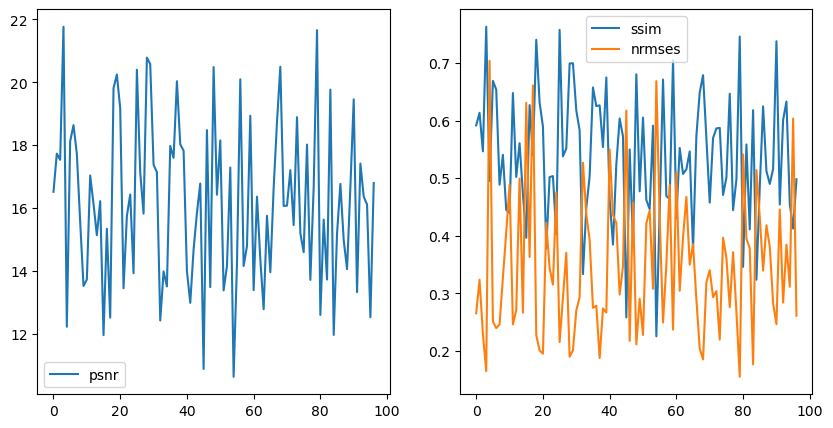

In [9]:
plt.figure(figsize=(10,5))

plt.subplot(121)
plt.plot(psnrs, label="psnr")

plt.legend()


plt.subplot(122)
plt.plot(ssims, label="ssim")
plt.plot(nrmses, label="nrmses")
plt.legend()